## Exam 

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score


In [ ]:
## load the dataset
df=pd.read_csv("/Users/mac/Desktop/Machine Learning/datasets/housing_train.csv")

print("Shape:", df.shape)
print("First 5 rows:", df.head())
print("Column names:", df.columns)
print("Info:", df.info())
print("Summary:", df.describe())

Shape: (1460, 81)
   Id  MSSubClass MSZoning  ...  SaleType  SaleCondition SalePrice
0   1          60       RL  ...        WD         Normal    208500
1   2          20       RL  ...        WD         Normal    181500
2   3          60       RL  ...        WD         Normal    223500
3   4          70       RL  ...        WD        Abnorml    140000
4   5          60       RL  ...        WD         Normal    250000

[5 rows x 81 columns]
First 5 rows: None
Column names: Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'Bs

In [17]:
# Separate Features and target
X=df.drop(["SalePrice", "Id"], axis=1)
y=df["SalePrice"]

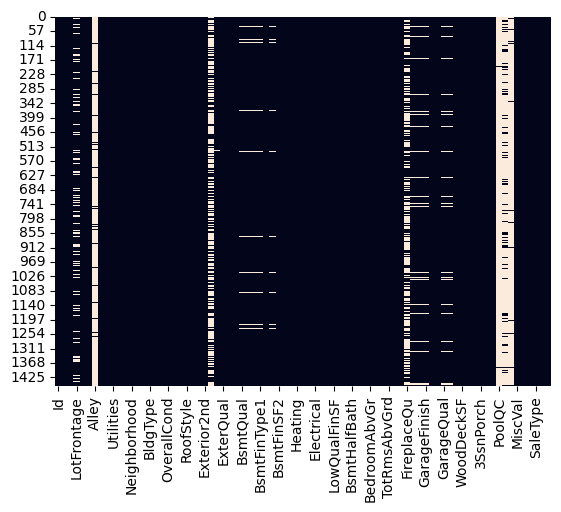

In [18]:
## Visualizing Missing Values
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [19]:
## Detecting missing values
missing_per=df.isnull().mean()*100

missing_per=missing_per.sort_values(ascending=False)
print(missing_per.head(20))

# columns with more than 80% missing values
cols_to_drop=missing_per[missing_per>80].index

# drop columns
df=df.drop(columns=cols_to_drop)

print("Dropped columns:")
print(cols_to_drop)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Id               0.000000
dtype: float64
Dropped columns:
Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='str')


In [20]:
# Detect Numerical and Categorical Columns
num_cols=X.select_dtypes(include=np.number).columns
cat_cols=X.select_dtypes(exclude=np.number).columns

# num_cols=X.select_dtypes(include=["int", "float"]).columns
# cat_cols=X.select_dtypes(include=["object", "string"]).columns

print(num_cols)
print(cat_cols)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAi

In [21]:
### Filling Missing values

# creating numerical pipeline
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# create categorical pipeline
cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [22]:
######### COMBINE PIPELINE
preprocessor=ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MODELS

In [24]:
#####  Random Forest Regressor

model=Pipeline([
    ("preprocessing", preprocessor),
    ("randomforest",RandomForestRegressor(random_state=42))
])

# Fit
model.fit(X_train, y_train)

# Prediction
y_pred=model.predict(X_test)


# Evaluate
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 17408.137191780825
MSE: 808384987.248317
RMSE: 28432.11190271164
R2: 0.8946087864567146


In [25]:
#####  Linear Regression

from sklearn.linear_model import LinearRegression

lin_reg=Pipeline([
    ("preprocessing", preprocessor),
    ("lin_reg", LinearRegression())
])

lin_reg.fit(X_test, y_test)

lin_pred=lin_reg.predict(X_test)

In [26]:
###### Ridge
from sklearn.linear_model import Ridge
ridge=Pipeline([
    ("preprocessing", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

In [27]:
##### Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree=Pipeline([
    ("preprocessing", preprocessor),
    ("tree", DecisionTreeRegressor(max_depth=5))
])